<a href="https://colab.research.google.com/github/GR0409/Statistical-Learning-e21091/blob/main/Assignment_7_Kalman_Filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q. Analytical Derivation

Consider the filter model
\begin{align*}
x^{-}_k &= A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}, \\
y^{-}_k &= H_k\,x^{-}_k + z_k,
\end{align*}
where
$$x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1}),$$

Answer the followings:

1. Show that
$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-),$$
where
$$m_k^- = A_{k-1}m_{k-1},$$
and
$$
P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T.
$$

2. Show that
$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m).$$

3. Show that
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right).$$

4. Show that
$$x^{+}_k\triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) \sim \mathscr{N}(m_k, P_k),$$
where the updated mean $m_k$ and updated covariance $P_k$ are given by:
\begin{align*}
K_k &\triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}, \\
m_k &= m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-), \\
P_k &= (I - K_k H_k) P_k^-.
\end{align*}

5. Find
$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}]$  and
$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$.

<br>

**Answers**

1. $$E[x_k^-] = E[A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1}]$$

$$E[x_k^-] = A_{k-1}E[x_{k-1}^+] + G_{k-1}E[w_{k-1}]$$

Since $E[w_{k-1}] = 0$ and $E[x_{k-1}^+] = m_{k-1}$,

$$m_k^- = A_{k-1}m_{k-1}$$

$x_{k-1}^+$ and $w_{k-1}$ are independent.

$$\text{Var}(x_k^-) = \text{Var}(A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1})$$

$$\text{Var}(x_k^-) = A_{k-1}\text{Var}(x_{k-1}^+)A_{k-1}^T + G_{k-1}\text{Var}(w_{k-1})G_{k-1}^T$$

$$P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T$$

Since $x_k^-$ is a linear combination of Gaussian random variables, it is also Gaussian.

$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$$

<br>

2. Expectation to the measurement equation.

$$E[y_k^-] = E[H_k x_k^- + z_k] = H_k E[x_k^-] + E[z_k]$$

$$E[y_k^-] = H_k m_k^-$$

Variance operator. $x_k^-$ and $z_k$ are independent.

$$\text{Var}(y_k^-) = \text{Var}(H_k x_k^- + z_k) = H_k \text{Var}(x_k^-) H_k^T + \text{Var}(z_k)$$

$$\text{Var}(y_k^-) = H_k P_k^- H_k^T + \Sigma_m$$

So linear transformation of a Gaussian is Gaussian.

$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$$

<br>

3. $$\mu = \begin{bmatrix} \mathbb{E}[x_k^-] \\ \mathbb{E}[y_k^-] \end{bmatrix} = \begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix}$$

$\Sigma_{xy} = \text{Cov}(x_k^-, y_k^-)$

$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}[(x_k^- - \mathbb{E}[x_k^-])(y_k^- - \mathbb{E}[y_k^-])^T]$$

Substitute $y_k^- = H_k x_k^- + z_k$ and expectation,

$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}[(x_k^- - m_k^-)(H_k x_k^- + z_k - H_k m_k^-)^T]$$

$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}[(x_k^- - m_k^-)(H_k(x_k^- - m_k^-) + z_k)^T]$$

$(A + B)^T = A^T + B^T$,

$$= \mathbb{E}[(x_k^- - m_k^-)((x_k^- - m_k^-)^T H_k^T + z_k^T)]$$

$$= \mathbb{E}[(x_k^- - m_k^-)(x_k^- - m_k^-)^T H_k^T] + \mathbb{E}[(x_k^- - m_k^-)z_k^T]$$

Since $H_k^T$ is deterministic, it pulls out.

Since $x_k^-$ and $z_k$ are independent, their expectation of products is the product of expectations ($\mathbb{E}[z_k^T] = 0$),

$$= \mathbb{E}[(x_k^- - m_k^-)(x_k^- - m_k^-)^T]H_k^T + \mathbb{E}[x_k^- - m_k^-]\mathbb{E}[z_k^T]$$

$$= P_k^- H_k^T + 0 = P_k^- H_k^T$$

The lower off-diagonal block is,

$\text{Cov}(y_k^-, x_k^-) = \text{Cov}(x_k^-, y_k^-)^T = (P_k^- H_k^T)^T = H_k P_k^-$

$$\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}$$

<br>

4. $$\begin{bmatrix} X \\ Y \end{bmatrix} \sim \mathscr{N}\left(\begin{bmatrix} \mu_X \\ \mu_Y \end{bmatrix}, \begin{bmatrix} \Sigma_{XX} & \Sigma_{XY} \\ \Sigma_{YX} & \Sigma_{YY} \end{bmatrix}\right)$$

The conditional distribution $X \mid Y=y$ is Gaussian with,

$$\mu_{X|Y} = \mu_X + \Sigma_{XY}\Sigma_{YY}^{-1}(y - \mu_Y)$$

$$\Sigma_{X|Y} = \Sigma_{XX} - \Sigma_{XY}\Sigma_{YY}^{-1}\Sigma_{YX}$$

Substitute $X = x_k^-$, $Y = y_k^-$, $y = y_k^{\mathrm{obs}}$,

$$m_k = m_k^- + (P_k^- H_k^T)(H_k P_k^- H_k^T + \Sigma_m)^{-1}(y_k^{\mathrm{obs}} - H_k m_k^-)$$

Define the Kalman Gain $K_k \triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$

$$m_k = m_k^- + K_k (y_k^{\mathrm{obs}} - H_k m_k^-)$$

$$P_k = P_k^- - (P_k^- H_k^T)(H_k P_k^- H_k^T + \Sigma_m)^{-1}(H_k P_k^-)$$

$$P_k = P_k^- - K_k (H_k P_k^-)$$

$$P_k = (I - K_k H_k) P_k^-$$

<br>

5. $$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}] = m_k$$

$$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) = P_k$$


# Q. 1-D Example

Consider the scalar linear-Gaussian filter model
\begin{aligned}
x^-_k &= a\,x^+_{k-1} + w_{k-1},\qquad w_{k-1}\sim\mathscr N(0,q),\\
y^-_k &= h\,x^-_k + z_k,\qquad\;\;\;\; z_k\sim\mathscr N(0,r),
\end{aligned}
with prior $x_0\sim \mathscr{N}(m_0,P_0)$. Define $Y_{k}=\{y^{\mathrm{obs}}_1,\dots,y^{\mathrm{obs}}_{k}\}$.

Answer the following:

1. Show that
\begin{aligned}
m_k^- &= a\,m_{k-1},\\
P_k^- &= a^2 P_{k-1} + q.
\end{aligned}

2. Show that
\begin{aligned}
m_k &= m_k^- + K_k\,v_k
= m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr),\\
P_k &= (1 - K_k h)\,P_k^-
= \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^- .
\end{aligned}

3. Show that the predictive measurement distribution (before seeing $y_k$):
\begin{align*}
p(y^-_k | Y_{k-1})=\mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr).
\end{align*}

4. Show that the posterior-predictive measurement distribution (after filtering on $y_k$):
\begin{align*}
p(y^-_k\mid Y_k)=\mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr).
\end{align*}

5. For suitable numerical values for $a,q,h,r$ animate the above to prior distribution and the posterior distribution.

<br>

**Answers**

1. $A_{k-1} = a$, $G_{k-1} = 1$, $\Sigma_p = q$, $H_k = h$, and $\Sigma_m = r$.

$$m_k^- = a m_{k-1}$$

$$P_k^- = a(P_{k-1})a + (1)q(1) = a^2 P_{k-1} + q$$

<br>

2. Innovation covariance,

$S_k = h P_k^- h + r = h^2 P_k^- + r$

Kalman Gain,

$K_k = P_k^- h S_k^{-1} = \frac{P_k^- h}{S_k}$

Mean $$m_k = m_k^- + K_k(y_k^{\text{obs}} - h m_k^-)$$

Covariance $$P_k = (1 - K_k h)P_k^- = \left(1 - \frac{P_k^- h^2}{S_k}\right)P_k^-$$

<br>

3. This relies on the prior state $m_k^-$,

Mean is $h m_k^-$ and Variance is $h^2 P_k^- + r$

So,

$$p(y_k^- \mid Y_{k-1}) = \mathscr{N}(h m_k^-, h^2 P_k^- + r)$$

<br>

4. This relies on the updated state $m_k$,

Mean is $h m_k$ and Variance is $h^2 P_k + r$

So,

$$p(y_k^- \mid Y_k) = \mathscr{N}(h m_k, h^2 P_k + r)$$

<br>

5.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.stats import norm
from IPython.display import HTML

# Define Numerical Parameters
a, q, h, r = 1.0, 0.2, 1.0, 1.5
initial_m, initial_P = 0.0, 2.0
time_steps = 20

fig, ax = plt.subplots(figsize=(10, 6))
x_axis = np.linspace(-15, 15, 1000)

# 1. Pre-calculate all states to prevent rendering bugs in Colab
frames_data = []
current_m = initial_m
current_P = initial_P
current_true = 0.0

for _ in range(time_steps):
    # Simulate true system
    current_true = a * current_true + np.random.normal(0, np.sqrt(q))
    y_obs = h * current_true + np.random.normal(0, np.sqrt(r))

    # Prediction Step
    m_minus = a * current_m
    P_minus = (a**2) * current_P + q

    # Update Step
    S = (h**2) * P_minus + r
    K = (P_minus * h) / S
    current_m = m_minus + K * (y_obs - h * m_minus)
    current_P = (1 - K * h) * P_minus

    # Store the data for this frame
    frames_data.append((current_true, y_obs, m_minus, P_minus, current_m, current_P))

# 2. Define the animation function
def animate(i):
    ax.clear()

    # Unpack the pre-calculated data for this frame
    true_val, obs_val, m_prior, p_prior, m_post, p_post = frames_data[i]

    # Generate Probability Density Functions
    prior_pdf = norm.pdf(x_axis, m_prior, np.sqrt(p_prior))
    posterior_pdf = norm.pdf(x_axis, m_post, np.sqrt(p_post))

    # Plotting
    ax.plot(x_axis, prior_pdf, label='Prior $p(x_k^- | Y_{k-1})$', color='blue', linewidth=2)
    ax.plot(x_axis, posterior_pdf, label='Posterior $p(x_k^+ | Y_k)$', color='green', linewidth=2)
    ax.axvline(obs_val, color='red', linestyle='--', label=f'Observation ($y^{{obs}}$)')
    ax.axvline(true_val, color='black', linestyle='-', label='True State')

    # Formatting
    ax.set_ylim(0, max(np.max(prior_pdf), np.max(posterior_pdf)) + 0.1)
    ax.set_xlim(-15, 15)
    ax.set_title(f'1D Kalman Filter Evolution - Step {i+1}')
    ax.set_ylabel('Probability Density')
    ax.set_xlabel('State Space')
    ax.legend(loc='upper left')

# 3. Create the animation
ani = animation.FuncAnimation(fig, animate, frames=time_steps, repeat=False)

# Close the static plot so it doesn't show up empty above our video player
plt.close()

# 4. Display inside the Notebook
HTML(ani.to_jshtml())

# Q. 2D-Position Estimation

## Part A

Consider a two-dimensional constant-velocity dynamical system. The hidden state at time step $k$ is

$$
x_k =
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where $(p_x(k),p_y(k))$ denote the position components and $(v_x(k),v_y(k))$ denote the velocity components.

The measurement consists only of the two position components:

$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The linear Gaussian state-space filter model is

$$
x^-_k = A x^+_{k-1} + G w_{k-1},
$$

$$
y^-_k = Hx^+_k + z_k,
$$

where

$$
w_{k-1} \sim \mathscr{N}(0,\Sigma_p),
\qquad
z_k \sim \mathscr{N}(0,\Sigma_m).
$$

The process noise sequence $w_k$, measurement noise sequence $z_k$, and the initial state are assumed mutually independent.

Show that:

$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
$$



$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix},
$$

and

$$
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$

<br>

**Answer**

Matrix A,

From basic constant velocity kinematics,

$p_x(k) = p_x(k-1) + v_x(k-1)\Delta t$

$p_y(k) = p_y(k-1) + v_y(k-1)\Delta t$

$v_x(k) = v_x(k-1)$

$v_y(k) = v_y(k-1)$

Representing in matrix form $x_k^- = A x_{k-1}^+$ directly yields,

$$A = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

Matrix H,

We only measure positions $p_x$ and $p_y$.

$y_k = [p_x, p_y]^T$.

Extracting this from the state vector $x = [p_x, p_y, v_x, v_y]^T$,

$$H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}$$

Matrix G,

Process noise $w_{k-1}$ represents acceleration variations.

Position update with acceleration,

$p = p_0 + v_0\Delta t + \frac{1}{2}a\Delta t^2$

$v = v_0 + a\Delta t$

Random acceleration vector $[a_x, a_y]^T$,

$$G = \begin{bmatrix} \frac{1}{2}\Delta t^2 & 0 \\ 0 & \frac{1}{2}\Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix}$$

## Part B

Develop a python based method to filter a sequence of noisy GPS obtained position meaurements.

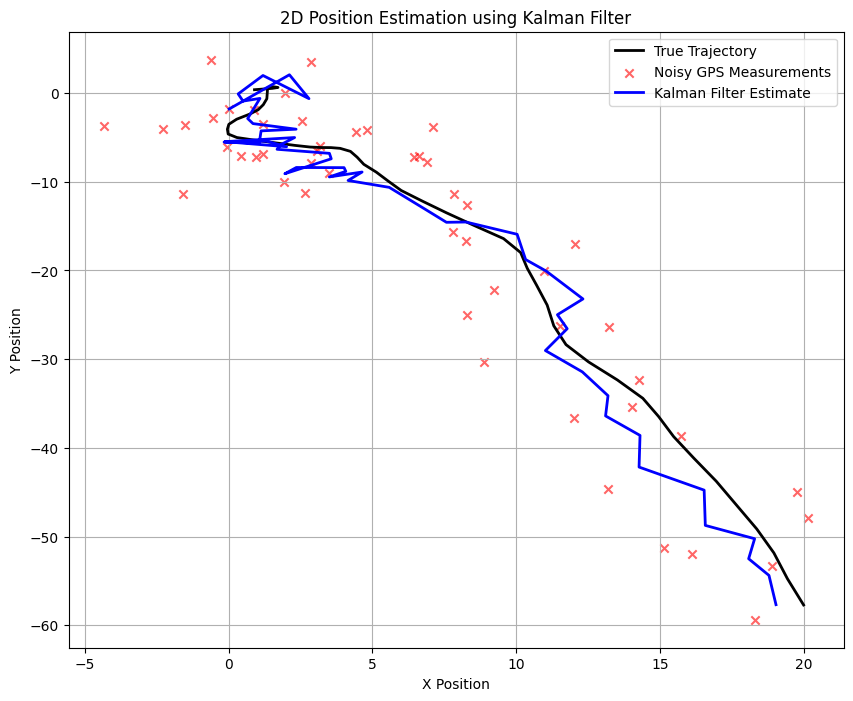

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def generate_trajectory(num_steps, dt, process_noise_var, measurement_noise_var):
    """Generates true trajectory and noisy GPS measurements."""
    A = np.array([[1, 0, dt, 0], [0, 1, 0, dt], [0, 0, 1, 0], [0, 0, 0, 1]])
    H = np.array([[1, 0, 0, 0], [0, 1, 0, 0]])
    G = np.array([[0.5*dt**2, 0], [0, 0.5*dt**2], [dt, 0], [0, dt]])

    true_states = np.zeros((num_steps, 4))
    measurements = np.zeros((num_steps, 2))

    # Initial state: x=0, y=0, vx=1, vy=0.5
    current_state = np.array([0, 0, 1.0, 0.5])

    for i in range(num_steps):
        # Add process noise (acceleration disturbances)
        w = np.random.normal(0, np.sqrt(process_noise_var), 2)
        current_state = A @ current_state + G @ w
        true_states[i] = current_state

        # Add measurement noise (GPS inaccuracies)
        z = np.random.normal(0, np.sqrt(measurement_noise_var), 2)
        measurements[i] = H @ current_state + z

    return true_states, measurements

def filter_gps_measurements(measurements, dt, process_noise_var, measurement_noise_var):
    """Filters the sequence of noisy 2D position measurements."""
    num_steps = len(measurements)

    A = np.array([[1, 0, dt, 0], [0, 1, 0, dt], [0, 0, 1, 0], [0, 0, 0, 1]])
    H = np.array([[1, 0, 0, 0], [0, 1, 0, 0]])
    G = np.array([[0.5*dt**2, 0], [0, 0.5*dt**2], [dt, 0], [0, dt]])

    Sigma_p = np.eye(2) * process_noise_var
    Q = G @ Sigma_p @ G.T
    R = np.eye(2) * measurement_noise_var

    # Initialize State: Use first measurement, assume zero initial velocity
    m = np.array([measurements[0, 0], measurements[0, 1], 0, 0])
    # High initial uncertainty for velocity
    P = np.diag([measurement_noise_var, measurement_noise_var, 10.0, 10.0])

    filtered_states = np.zeros((num_steps, 4))

    for i in range(num_steps):
        # 1. Prediction Step
        m_minus = A @ m
        P_minus = A @ P @ A.T + Q

        # 2. Update Step
        y_obs = measurements[i]
        S = H @ P_minus @ H.T + R
        K = P_minus @ H.T @ np.linalg.inv(S)

        m = m_minus + K @ (y_obs - H @ m_minus)
        P = (np.eye(4) - K @ H) @ P_minus

        filtered_states[i] = m

    return filtered_states

# --- Execution and Visualization ---
dt = 1.0
process_noise_var = 0.05      # Variance of acceleration disturbances
measurement_noise_var = 5.0   # Variance of GPS noise
num_steps = 50

# 1. Generate Data
true_states, noisy_measurements = generate_trajectory(num_steps, dt, process_noise_var, measurement_noise_var)

# 2. Apply Kalman Filter
filtered_states = filter_gps_measurements(noisy_measurements, dt, process_noise_var, measurement_noise_var)

# 3. Plot Results
plt.figure(figsize=(10, 8))
plt.plot(true_states[:, 0], true_states[:, 1], label='True Trajectory', color='black', linewidth=2)
plt.scatter(noisy_measurements[:, 0], noisy_measurements[:, 1], label='Noisy GPS Measurements', color='red', marker='x', alpha=0.6)
plt.plot(filtered_states[:, 0], filtered_states[:, 1], label='Kalman Filter Estimate', color='blue', linewidth=2)

plt.title('2D Position Estimation using Kalman Filter')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.legend()
plt.grid(True)
plt.show()